# tcpyVPI: ERA5 vPI and GPIv example read+calculate+plot from monthly and hourly data

This notebook demonstrates how to use the tcpyVPI package to compute
ventilated Potential Intensity (vPI) and Genesis Potential Index (GPIv)
from ERA5 monthly and hourly reanalysis data.

IMPORTANT: this notebook reads ERA5 data remotely via the NCAR THREDDS server. Sometimes THREDDS throws an "NetCDF: DAP server error" when reading the data -- it seems to be somewhat random whether/when it happens and is not due to this notebook. If it happens, run it again.

Note: the package includes wrapper functions to read+calculate+plot automatically for ERA5 data (monthly or hourly) if desired -- see other python notebook. This notebook shows you how to do it yourself step by step.


**Cite this package:**  
Chavas, D. Sanchez, J. O., and A. Kruskie (2026). *tcpyVPI*. https://doi.org/10.5281/zenodo.19319996

[![PyPI version](https://img.shields.io/pypi/v/tcpyVPI.svg)](https://pypi.org/project/tcpyVPI/)
[![DOI](https://zenodo.org/badge/DOI/10.5281/zenodo.19319996.svg)](https://doi.org/10.5281/zenodo.19319996)

**Key Features:**
- Load ERA5 monthly and hourly data via THREDDS
- Compute vPI and GPIv (Chavas et al 2025) for a specific year+month

**Author:** Dan Chavas, Aaron Kruskie, Jose Sanchez (2025)

In [1]:
# Install dependencies
!pip install -q tcpyPI tcpyVPI netCDF4 cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 29.8 MB/s eta 0:00:00


In [2]:
# ==== IMPORTS ====
import calendar
from datetime import datetime

import xarray as xr
import numpy as np
from matplotlib import pyplot as plt
import cartopy.crs as ccrs

from tcpyVPI import compute_gpiv_from_dataset

## Choose ERA5 source and timestamp

Set `DATA_SOURCE = "monthly"` for the monthly mean ERA5 product, or `"hourly"` for the hourly product.

In [3]:
# ==== USER SETTINGS ====
DATA_SOURCE = "monthly"   # "monthly" or "hourly"

YEAR = 2022
MONTH = 9

# Only used for hourly
DAY = 15
HOUR = 12

## THREDDS base URLs and manual URL builders

These URL patterns follow the same ERA5 THREDDS layout used in the package loader.

In [4]:
# ==== ERA5 THREDDS BASE PATHS ====
THREDDS_BASE = "https://thredds.rda.ucar.edu/thredds/dodsC/files/g"

# Monthly mean dataset (d633001)
BASE_MMEAN_SFC = f"{THREDDS_BASE}/d633001_nc/e5.moda.an.sfc"
BASE_MMEAN_PL = f"{THREDDS_BASE}/d633001_nc/e5.moda.an.pl"

# Hourly dataset (d633000)
BASE_HOURLY_SFC = f"{THREDDS_BASE}/d633000/e5.oper.an.sfc"
BASE_HOURLY_PL = f"{THREDDS_BASE}/d633000/e5.oper.an.pl"

SURFACE_VARS = {
    "SSTK": ("034_sstk", "sc"),
    "SP":   ("134_sp",   "sc"),
}

PRESSURE_VARS = {
    "T":  ("130_t",  "sc"),
    "U":  ("131_u",  "uv"),
    "V":  ("132_v",  "uv"),
    "Q":  ("133_q",  "sc"),
    "VO": ("138_vo", "sc"),
}

def monthly_mean_url(var_name, year, is_surface=True):
    if is_surface:
        code, suffix = SURFACE_VARS[var_name]
        base = BASE_MMEAN_SFC
        kind = "sfc"
    else:
        code, suffix = PRESSURE_VARS[var_name]
        base = BASE_MMEAN_PL
        kind = "pl"

    fname = (
        f"e5.moda.an.{kind}.128_{code}.ll025{suffix}."
        f"{year}010100_{year}120100.nc"
    )
    return f"{base}/{year}/{fname}"

def hourly_surface_url(var_name, year, month):
    code, suffix = SURFACE_VARS[var_name]
    last_day = calendar.monthrange(year, month)[1]
    y = f"{year}"
    m = f"{month:02d}"
    fname = (
        f"e5.oper.an.sfc.128_{code}.ll025{suffix}."
        f"{y}{m}0100_{y}{m}{last_day:02d}23.nc"
    )
    return f"{BASE_HOURLY_SFC}/{y}{m}/{fname}"

def hourly_pressure_url(var_name, year, month, day):
    code, suffix = PRESSURE_VARS[var_name]
    y = f"{year}"
    m = f"{month:02d}"
    d = f"{day:02d}"
    fname = (
        f"e5.oper.an.pl.128_{code}.ll025{suffix}."
        f"{y}{m}{d}00_{y}{m}{d}23.nc"
    )
    return f"{BASE_HOURLY_PL}/{y}{m}/{fname}"

## Open the remote datasets manually

In [5]:
def debug_print(name, arr, url):
    print(f"\n{name} loaded")
    print(f"  URL: {url}")
    print(f"  dims: {arr.dims}")
    print(f"  shape: {arr.shape}")


In [6]:
if DATA_SOURCE == "monthly":
    # Monthly mean: each file contains all 12 months for a year.
    idx = MONTH - 1

    url = monthly_mean_url("SSTK", YEAR, is_surface=True)
    SSTK = xr.open_dataset(url).SSTK.isel(time=idx)
    debug_print("SSTK", SSTK, url)

    url = monthly_mean_url("SP", YEAR, is_surface=True)
    SP = xr.open_dataset(url).SP.isel(time=idx)
    debug_print("SP", SP, url)

    url = monthly_mean_url("T", YEAR, is_surface=False)
    T = xr.open_dataset(url).T.isel(time=idx)
    debug_print("T", T, url)

    url = monthly_mean_url("Q", YEAR, is_surface=False)
    Q = xr.open_dataset(url).Q.isel(time=idx)
    debug_print("Q", Q, url)

    url = monthly_mean_url("U", YEAR, is_surface=False)
    U = xr.open_dataset(url).U.isel(time=idx)
    debug_print("U", U, url)

    url = monthly_mean_url("V", YEAR, is_surface=False)
    V = xr.open_dataset(url).V.isel(time=idx)
    debug_print("V", V, url)

    url = monthly_mean_url("VO", YEAR, is_surface=False)
    VO = xr.open_dataset(url).VO.isel(time=idx)
    debug_print("VO", VO, url)

elif DATA_SOURCE == "hourly":
    target_time = datetime(YEAR, MONTH, DAY, HOUR)

    # Surface variables live in monthly files.
    url = hourly_surface_url("SSTK", YEAR, MONTH)
    ds_sstk = xr.open_dataset(url)
    SSTK = ds_sstk.SSTK.sel(time=target_time, method="nearest")
    debug_print("SSTK", SSTK, url)

    url = hourly_surface_url("SP", YEAR, MONTH)
    ds_sp = xr.open_dataset(url)
    SP = ds_sp.SP.sel(time=target_time, method="nearest")
    debug_print("SP", SP, url)

    # Pressure-level variables live in daily files.
    url = hourly_pressure_url("T", YEAR, MONTH, DAY)
    T = xr.open_dataset(url).T.sel(time=target_time, method="nearest")
    debug_print("T", T, url)

    url = hourly_pressure_url("Q", YEAR, MONTH, DAY)
    Q = xr.open_dataset(url).Q.sel(time=target_time, method="nearest")
    debug_print("Q", Q, url)

    url = hourly_pressure_url("U", YEAR, MONTH, DAY)
    U = xr.open_dataset(url).U.sel(time=target_time, method="nearest")
    debug_print("U", U, url)

    url = hourly_pressure_url("V", YEAR, MONTH, DAY)
    V = xr.open_dataset(url).V.sel(time=target_time, method="nearest")
    debug_print("V", V, url)

    url = hourly_pressure_url("VO", YEAR, MONTH, DAY)
    VO = xr.open_dataset(url).VO.sel(time=target_time, method="nearest")
    debug_print("VO", VO, url)

else:
    raise ValueError("DATA_SOURCE must be 'monthly' or 'hourly'")


SSTK loaded
  URL: https://thredds.rda.ucar.edu/thredds/dodsC/files/g/d633001_nc/e5.moda.an.sfc/2022/e5.moda.an.sfc.128_034_sstk.ll025sc.2022010100_2022120100.nc
  dims: ('latitude', 'longitude')
  shape: (721, 1440)

SP loaded
  URL: https://thredds.rda.ucar.edu/thredds/dodsC/files/g/d633001_nc/e5.moda.an.sfc/2022/e5.moda.an.sfc.128_134_sp.ll025sc.2022010100_2022120100.nc
  dims: ('latitude', 'longitude')
  shape: (721, 1440)

T loaded
  URL: https://thredds.rda.ucar.edu/thredds/dodsC/files/g/d633001_nc/e5.moda.an.pl/2022/e5.moda.an.pl.128_130_t.ll025sc.2022010100_2022120100.nc
  dims: ('level', 'latitude', 'longitude')
  shape: (37, 721, 1440)

Q loaded
  URL: https://thredds.rda.ucar.edu/thredds/dodsC/files/g/d633001_nc/e5.moda.an.pl/2022/e5.moda.an.pl.128_133_q.ll025sc.2022010100_2022120100.nc
  dims: ('level', 'latitude', 'longitude')
  shape: (37, 721, 1440)

U loaded
  URL: https://thredds.rda.ucar.edu/thredds/dodsC/files/g/d633001_nc/e5.moda.an.pl/2022/e5.moda.an.pl.128_131_u.

## Merge into the dataset expected by `compute_gpiv_from_dataset()`

In [7]:
ds = xr.merge(
    [Q, T, U, V, SP.rename("SP"), SSTK.rename("SSTK"), VO.rename("VO")],
    compat="override",
    join="outer",
)

# Ensure required interpolation target levels exist and are unique.
lev_coords = np.sort(np.array(list(set(ds.level.values.tolist() + [850, 600, 200]))))[::-1]
ds = ds.interp(level=lev_coords)

ds

<xarray.Dataset> Size: 2GB
Dimensions:    (latitude: 721, longitude: 1440, level: 37)
Coordinates:
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * level      (level) float64 296B 1e+03 975.0 950.0 925.0 ... 5.0 3.0 2.0 1.0
    time       datetime64[ns] 8B 2022-09-01
Data variables:
    Q          (level, latitude, longitude) float64 307MB 0.002307 ... 3.674e-06
    T          (level, latitude, longitude) float64 307MB 267.3 267.3 ... 269.9
    U          (level, latitude, longitude) float64 307MB -0.0001078 ... -0.0...
    V          (level, latitude, longitude) float64 307MB 0.0001678 ... 0.000473
    SP         (latitude, longitude) float32 4MB ...
    SSTK       (latitude, longitude) float32 4MB ...
    VO         (level, latitude, longitude) float64 307MB -1.546e-07 ... -9.9...
Attributes: (12/15)
    long_name:                                          Specific humidity
    short_name:                                         q
    units:                                              kg kg**-1
    original_format:                                    WMO GRIB 1 with ECMWF...
    ecmwf_local_table:                                  128
    ecmwf_parameter:                                    133
    ...                                                 ...
    rda_dataset:                                        ds633.1
    rda_dataset_url:                                    https:/rda.ucar.edu/d...
    rda_dataset_doi:                                    DOI: 10.5065/P8GT-0R61
    rda_dataset_group:                                  ERA5 monthly mean atm...
    QuantizeGranularBitGroomNumberOfSignificantDigits:  7
    _ChunkSizes:                                        [   1   37  721 1440]

## Run the package computation on the manually assembled ERA5 dataset

In [8]:
results_ds = compute_gpiv_from_dataset(ds)
results_ds

  Calculating Potential Intensity (PI)...
  Calculating Vertical Wind Shear (VWS)...
  Calculating Entropy Deficit (Chi)...
T600: min = 216.72251892089844 , max = 282.0955810546875
rv600: min = 9.354742559199658e-06 , max = 0.00861571315893317
sm_600: min = -85.86392267098262 , max = 255.29277316997482
sm_star_600: min = -85.72647980592001 , max = 291.6621473505859
  Calculating Capped Vorticity (eta_c)...
  Combining components for final GPIv...


/usr/local/lib/python3.13/dist-packages/xarray/computation/apply_ufunc.py:818: RuntimeWarning: divide by zero encountered in divide
  result_data = func(*input_data)


<xarray.Dataset> Size: 58MB
Dimensions:            (latitude: 721, longitude: 1440)
Coordinates:
  * latitude           (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude          (longitude) float64 12kB 0.0 0.25 0.5 ... 359.5 359.8
    time               datetime64[ns] 8B 2022-09-01
    level              float64 8B 850.0
Data variables:
    GPIv               (latitude, longitude) float64 8MB nan nan nan ... nan nan
    vPI                (latitude, longitude) float64 8MB nan nan nan ... nan nan
    PI                 (latitude, longitude) float64 8MB nan nan nan ... nan nan
    ventilation_index  (latitude, longitude) float64 8MB nan nan nan ... nan nan
    VWS                (latitude, longitude) float64 8MB 0.0005493 ... 0.0005493
    Chi                (latitude, longitude) float64 8MB nan nan nan ... nan nan
    eta_c              (latitude, longitude) float64 8MB 3.7e-05 ... 3.7e-05

In [9]:
vPI = results_ds.vPI
PI = results_ds.PI
eta_c = results_ds.eta_c
GPIv = results_ds.GPIv
ventilation_index = results_ds.ventilation_index

## Quick plots

/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


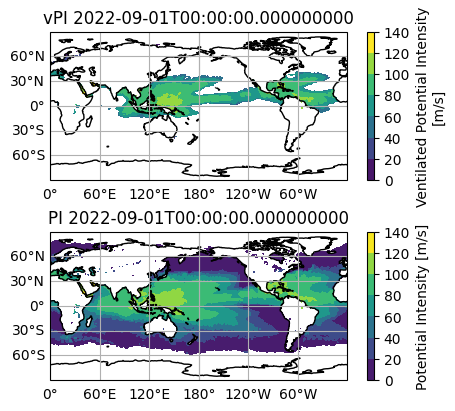

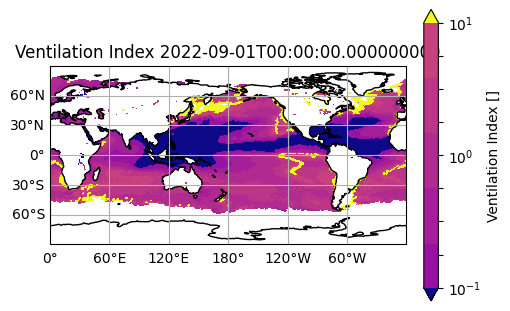

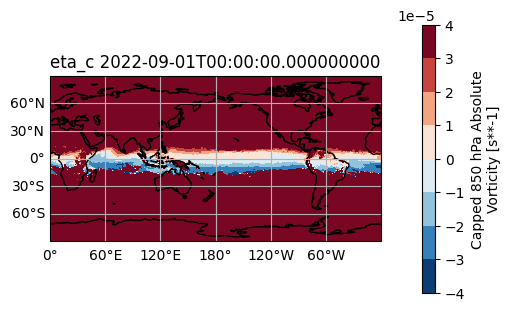

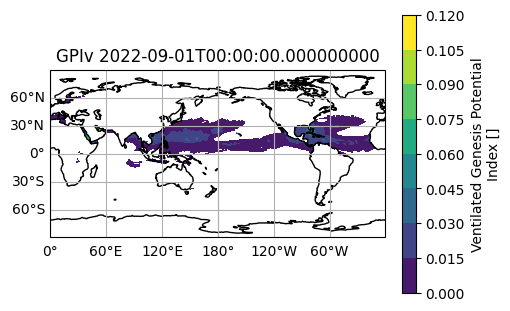

In [10]:
centlong = 180

# -------------------------------------------------
# 1. vPI and PI (existing)
# -------------------------------------------------
fig, ax = plt.subplots(
    2,
    figsize=(5, 4),
    constrained_layout=True,
    subplot_kw={"projection": ccrs.PlateCarree(central_longitude=centlong)},
    dpi=100,
)

xr.plot.contourf(vPI, ax=ax[0], transform=ccrs.PlateCarree())
ax[0].set_title(f"vPI {ds.time.values}")
ax[0].coastlines()
gl = ax[0].gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False

xr.plot.contourf(PI, ax=ax[1], transform=ccrs.PlateCarree())
ax[1].set_title(f"PI {ds.time.values}")
ax[1].coastlines()
gl = ax[1].gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False


# -------------------------------------------------
# 2. Ventilation Index (log scale)
# -------------------------------------------------
from matplotlib.colors import LogNorm
from matplotlib import cm

fig, ax = plt.subplots(
    1,
    figsize=(5, 3),
    constrained_layout=True,
    subplot_kw={"projection": ccrs.PlateCarree(central_longitude=centlong)},
    dpi=100,
)

lev_exp = np.linspace(-1, 1, 25)
levs = np.power(10, lev_exp)

xr.plot.contourf(
    ventilation_index,
    ax=ax,
    norm=LogNorm(),
    levels=levs,
    transform=ccrs.PlateCarree(),
    cmap=cm.plasma,
)

ax.set_title(f"Ventilation Index {ds.time.values}")
ax.coastlines()
gl = ax.gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False


# -------------------------------------------------
# 3. eta_c
# -------------------------------------------------
fig, ax = plt.subplots(
    1,
    figsize=(5, 3),
    constrained_layout=True,
    subplot_kw={"projection": ccrs.PlateCarree(central_longitude=centlong)},
    dpi=100,
)

xr.plot.contourf(eta_c, ax=ax, transform=ccrs.PlateCarree())

ax.set_title(f"eta_c {ds.time.values}")
ax.coastlines()
gl = ax.gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False


# -------------------------------------------------
# 4. GPIv
# -------------------------------------------------
fig, ax = plt.subplots(
    1,
    figsize=(5, 3),
    constrained_layout=True,
    subplot_kw={"projection": ccrs.PlateCarree(central_longitude=centlong)},
    dpi=100,
)

xr.plot.contourf(GPIv, ax=ax, transform=ccrs.PlateCarree())

ax.set_title(f"GPIv {ds.time.values}")
ax.coastlines()
gl = ax.gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False

## Optional debug cells

Use these if you want to inspect the exact URLs being opened.

In [11]:
if DATA_SOURCE == "monthly":
    print(monthly_mean_url("SSTK", YEAR, is_surface=True))
    print(monthly_mean_url("SP", YEAR, is_surface=True))
    print(monthly_mean_url("T", YEAR, is_surface=False))
else:
    print(hourly_surface_url("SSTK", YEAR, MONTH))
    print(hourly_surface_url("SP", YEAR, MONTH))
    print(hourly_pressure_url("T", YEAR, MONTH, DAY))

https://thredds.rda.ucar.edu/thredds/dodsC/files/g/d633001_nc/e5.moda.an.sfc/2022/e5.moda.an.sfc.128_034_sstk.ll025sc.2022010100_2022120100.nc
https://thredds.rda.ucar.edu/thredds/dodsC/files/g/d633001_nc/e5.moda.an.sfc/2022/e5.moda.an.sfc.128_134_sp.ll025sc.2022010100_2022120100.nc
https://thredds.rda.ucar.edu/thredds/dodsC/files/g/d633001_nc/e5.moda.an.pl/2022/e5.moda.an.pl.128_130_t.ll025sc.2022010100_2022120100.nc
